# 03 — Choosing your tier

## The question

> The same signal exists three times: as `reading`, as `reading_1m` and as
> `reading_1h`. I need a number. Which one do I query?

Notebook 04 argues that a rollup is a different *estimator*. This notebook is about
the other axis: what each tier can and cannot *show you*, so that the choice is made
by the question and not by whichever table was fastest to type.

The house rule this series follows is **rollups by default, raw when the question is
about the raw**. The point of the notebook is to say exactly when that is.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from notebooks._data import connect, storm_window
from notebooks._style import apply_style, save, stamp, trend

apply_style()
pd.set_option("display.width", 130)

conn = connect()
storm_start, storm_end = (pd.Timestamp(t) for t in storm_window())
TIERS = {"reading": "ts", "reading_1m": "bucket", "reading_1h": "bucket"}

## What each tier costs

The cheap thing to measure is the thing that does not change between runs: how many
rows a tier holds, and how many a question has to read.

In [2]:
# **No on-disk size.** `hypertable_size()` is the obvious thing to put in the
# column next to `rows`, and it was the first version of this cell. It is also
# the one number here that is *not* the same on your machine as on mine, so it
# cannot be stated in a lesson that has to be true on both:
#
# * a hypertable's size is measured in compressed chunks, and compression is a
#   per-chunk, write-order-dependent result — a different order of inserts gives
#   a different total;
# * it is measured in 8 kB pages, so the last partial page is counted whole.
#
# The first point cost a CI failure: the table is checked against what the
# notebook printed, and the notebook printed 1 043 MB here and something else on
# a runner. **A number that depends on the disk is a fact about one machine**, and
# this series claims only the kind that is not.
cost = pd.DataFrame(
    {
        "rows": {
            t: conn.execute(f"SELECT count(*) FROM {t}").fetchone()[0] for t in TIERS
        },
    }
)
cost["times smaller"] = (cost.rows["reading"] / cost.rows).round(0).astype(int)
day = ("2026-09-27", "2026-09-28")
cost["rows for one signal-day"] = {
    t: conn.execute(
        f"SELECT count(*) FROM {t} WHERE signal_id = 'AERATION:AHU-1:BLOWER_VALVE' "
        f"AND {col} >= %s AND {col} < %s",
        day,
    ).fetchone()[0]
    for t, col in TIERS.items()
}
print(cost.to_string())

               rows  times smaller  rows for one signal-day
reading     4239284              1                    34978
reading_1m   185455             23                     1038
reading_1h     5882            721                       24


```output
               rows  times smaller  rows for one signal-day
reading     4239284              1                    34978
reading_1h     5882            721                       24
reading_1m   185455             23                     1038
```

**The minute tier is 23 times smaller than the raw table and the hour tier is 721
times smaller**, and the same question — the blower valve on 27 September — reads
34,978 rows, 1,038 rows or 24 rows depending on where you ask it. For a dashboard
that is the entire argument. For an analysis it is only the opening one, because
the rows are not the same rows.

## What each tier keeps

A rollup is `avg`, `min`, `max` and a count per bucket per signal. Those four are all
it remembers. Ask each tier for the biggest thing that happened to lift-station flow —
the storm:

In [3]:
sig = "INFLUENT:LIFT:FLOW"
raw = pd.read_sql(f"SELECT ts, value FROM reading WHERE signal_id = '{sig}'", conn)
m1 = pd.read_sql(f"SELECT * FROM reading_1m WHERE signal_id = '{sig}'", conn)
h1 = pd.read_sql(f"SELECT * FROM reading_1h WHERE signal_id = '{sig}'", conn)

peaks = pd.Series(
    {
        "raw reading, maximum": raw.value.max(),
        "1 minute, largest mean": m1["mean"].max(),
        "1 minute, largest max": m1["max"].max(),
        "1 hour, largest mean": h1["mean"].max(),
        "1 hour, largest max": h1["max"].max(),
    }
)
print(
    pd.DataFrame(
        {
            "m3/h": peaks.round(1),
            "vs raw": (100 * (peaks / peaks.iloc[0] - 1)).round(1).astype(str) + " %",
        }
    ).to_string()
)

                          m3/h   vs raw
raw reading, maximum    5451.9    0.0 %
1 minute, largest mean  5437.4   -0.3 %
1 minute, largest max   5451.9    0.0 %
1 hour, largest mean    4151.9  -23.8 %
1 hour, largest max     5451.9    0.0 %


```output
                          m3/h   vs raw
raw reading, maximum    5451.9    0.0 %
1 minute, largest mean  5437.4   -0.3 %
1 minute, largest max   5451.9    0.0 %
1 hour, largest mean    4151.9  -23.8 %
1 hour, largest max     5451.9    0.0 %
```

**The hourly mean loses a quarter of the storm.** The biggest hour averages 4152 m³/h
against a true peak of 5452, **-23.8 %**, because the storm lasts two hours and an
hour is long enough to dilute it. The minute mean keeps almost all of it (**-0.3 %**),
and the `max` column keeps *all* of it, at either tier.

So the tier is not a fidelity dial from good to bad. The columns inside it answer
different questions: **`mean` is for level, `max` and `min` are for extremes, and `n`
is for how much to believe either.** A peak asked of a mean is the one mistake with
no error message.

Draw it, so the loss is seen and not only counted:

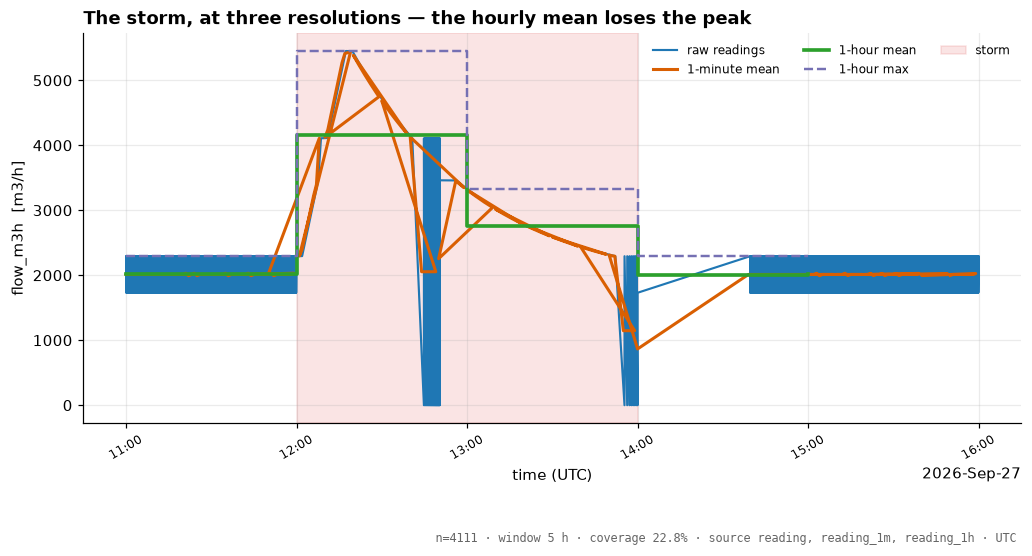

In [4]:
window = (raw.ts >= storm_start - pd.Timedelta(hours=1)) & (
    raw.ts < storm_end + pd.Timedelta(hours=2)
)
fig, ax = plt.subplots(figsize=(11, 4.6))
trend(ax, {"raw readings": raw[window].set_index("ts").value}, sig)
ax.plot(
    m1[
        (m1.bucket >= storm_start - pd.Timedelta(hours=1))
        & (m1.bucket < storm_end + pd.Timedelta(hours=2))
    ].set_index("bucket")["mean"],
    label="1-minute mean",
    linewidth=2,
)
hourly = h1[
    (h1.bucket >= storm_start - pd.Timedelta(hours=1))
    & (h1.bucket < storm_end + pd.Timedelta(hours=2))
]
ax.step(hourly.bucket, hourly["mean"], where="post", label="1-hour mean", linewidth=2.4)
ax.step(
    hourly.bucket,
    hourly["max"],
    where="post",
    label="1-hour max",
    linewidth=1.6,
    linestyle="--",
)
ax.axvspan(storm_start, storm_end, color="#d62728", alpha=0.12, label="storm")
ax.legend(loc="upper right", ncols=3, fontsize=8)
ax.set_title(
    "The storm, at three resolutions — the hourly mean loses the peak",
    loc="left",
    fontweight="bold",
)
stamp(
    ax,
    raw[window].set_index("ts").value,
    window="5 h",
    source="reading, reading_1m, reading_1h",
    expected_s=1,
)
save(fig, "03_storm_tiers")

The dashed line is what to plot when the question is "how bad did it get". The solid
hourly line is what most dashboards draw, and it is a picture of a storm about
three-quarters as bad as the one that happened.

## What no tier keeps except the raw one

Every column above is a statement about the *values*. The rollup has no `quality`
column at all — look at its definition: `avg(value)`, `min(value)`, `max(value)`,
`count(value)`, grouped by bucket, signal and source. Three consequences follow, and
each one is silent.

In [5]:
quality = pd.read_sql(
    "SELECT quality, count(*) AS readings, count(value) AS with_a_value "
    "FROM reading GROUP BY quality ORDER BY quality",
    conn,
)
print(quality.to_string(index=False))

flagged = pd.read_sql(
    "SELECT signal_id, min(ts) AS first, max(ts) AS last, count(*) AS uncertain "
    "FROM reading WHERE quality = 1 GROUP BY signal_id ORDER BY uncertain DESC",
    conn,
)
print()
print(flagged.to_string(index=False))

 quality  readings  with_a_value
       0   4239247       4239247
       1        36            36
       2         1             0

        signal_id                     first                      last  uncertain
AERATION:AHU-1:DO 2026-09-24 02:23:59+00:00 2026-09-24 03:22:31+00:00         35
EFFLUENT:FLOW:TSS 2026-09-25 20:23:59+00:00 2026-09-25 20:23:59+00:00          1


```output
 quality  readings  with_a_value
       0   4239247       4239247
       1        36            36
       2         1             0

        signal_id                     first                      last  uncertain
AERATION:AHU-1:DO 2026-09-24 02:23:59+00:00 2026-09-24 03:22:31+00:00         35
EFFLUENT:FLOW:TSS 2026-09-25 20:23:59+00:00 2026-09-25 20:23:59+00:00          1
```

Thirty-six readings are `Uncertain`, thirty-five of them on the dissolved-oxygen probe
in a single stretch on 24 September — the drifting sensor, flagged by the instrument
itself. And one reading is `Bad`, with no value. Ask the hourly rollup what it did
with the flagged ones:

In [6]:
do = "AERATION:AHU-1:DO"
raw_do = pd.read_sql(
    f"SELECT ts, value, quality FROM reading WHERE signal_id = '{do}'", conn
)
h1_do = pd.read_sql(f"SELECT * FROM reading_1h WHERE signal_id = '{do}'", conn)

for hour in pd.date_range("2026-09-24 02:00", periods=2, freq="1h", tz="UTC"):
    inside = raw_do[(raw_do.ts >= hour) & (raw_do.ts < hour + pd.Timedelta(hours=1))]
    rolled = h1_do[h1_do.bucket == hour].iloc[0]
    trusted = inside[inside.quality == 0]
    verdict = (
        f"mean {trusted.value.mean():.3f}"
        if len(trusted)
        else "no trusted reading at all"
    )
    print(
        f"{hour:%H:%M}  raw: {len(inside)} readings, "
        f"{int((inside.quality == 1).sum())} flagged Uncertain | "
        f"reading_1h: mean {rolled['mean']:.3f} mg/L, n = {int(rolled.n)} | "
        f"trusted only: {verdict}"
    )

02:00  raw: 21 readings, 21 flagged Uncertain | reading_1h: mean 2.199 mg/L, n = 21 | trusted only: no trusted reading at all
03:00  raw: 15 readings, 14 flagged Uncertain | reading_1h: mean 2.513 mg/L, n = 15 | trusted only: mean 1.997


```output
02:00  raw: 21 readings, 21 flagged Uncertain | reading_1h: mean 2.199 mg/L, n = 21 | trusted only: no trusted reading at all
03:00  raw: 15 readings, 14 flagged Uncertain | reading_1h: mean 2.513 mg/L, n = 15 | trusted only: mean 1.997
```

**In the 02:00 hour every reading was flagged — and the rollup reports a mean of 2.199
mg/L over n = 21 as though it were an ordinary hour.** Nothing in `mean`, `min`,
`max` or `n` says any of them were flagged. There is no trusted reading in that hour
to compare it with, so the honest value of the bucket is *nothing*, and the rollup has
no way to say so. The next hour is
worse in a subtler way: **14 of 15** readings are flagged, the one trusted reading says
**1.997** mg/L, and the rollup reports **2.513** — a mean dragged up by the drift
the instrument itself had marked as untrustworthy. The `Bad` reading is the same failure from the other side:
`count(value)` skips it, so it is not in `n` either, and its hour looks like a slightly
quiet hour of a healthy instrument.

That settles the second half of the rule, and it is not a matter of taste:

> **Any question that is about *whether to believe* a reading needs the raw table.**
> The rollups cannot answer it, because they have already forgotten.

## The decision, as a table

| the question is about… | use | because |
|---|---|---|
| the **level** or trend over hours or days | `reading_1h`, column `mean` | 24 rows a day instead of 34,978, and the loss is only detail |
| dynamics over **minutes** | `reading_1m`, columns `mean`, `max` | keeps the storm's peak to a third of a percent |
| how **bad** it got, or how low | `max` or `min` at *either* rollup | the only columns that keep extremes; `mean` dilutes them |
| how much to **believe** an hour | `n` | the rollup's only statement about evidence |
| whether a reading was **flagged** | `reading`, column `quality` | the rollups have no such column |
| an **estimator** argument — time- or flow-weighted, notebook 07 | `reading` | you must control the weights |
| a **change point** to the minute, notebook 10 | `reading_1m` or `reading` | an hour cannot date anything |

Two rows are worth underlining. The first is that **`max` at the hour tier is
better than `mean` at the minute tier for a peak**, which is not how the tiers are
usually ranked. The last but one is that **raw is not "more accurate"** — it is the
only tier that still has the columns the question needs.

## Takeaways

- **The tiers are 23× and 721× smaller** than the raw table, and a signal-day is
  **34,978**, **1,038** or **24** rows depending on where you ask.
- **The hourly mean loses -23.8 % of the storm's peak**; the minute mean loses
  **-0.3 %**; the `max` column loses nothing at either tier. Ask for extremes with
  `max`.
- **Rollups are quality-blind.** They averaged 35 `Uncertain` readings into an hour
  of dissolved oxygen and counted them in `n`, and a `Bad` reading is not counted at
  all. A question about trust needs the raw table.
- **The rule this series follows:** rollups by default, `max`/`min` for extremes,
  `n` for evidence, raw when the question is about the raw.

## Exercises

1. **Find the tier that breaks the storm.** The minute mean keeps 99.7 % of the peak
   here. Simulate a storm of one-quarter the length by editing the window and find the
   duration at which the *minute* mean starts to lose the peak too.
2. **Rank every signal by peak loss.** For each signal with at least 100 hourly
   buckets, compute `1 - max(hourly mean) / max(raw)`. Which signals lose the most,
   and what do they have in common?
3. **Count the flags.** Using only the rollups, try to find the hour of the dead lift
   sensor on 27 September. What is the smallest thing in `reading_1h` that gives it
   away — and would you have noticed it without being told?
4. **Write the tier chooser.** Turn the decision table into a function that takes a
   question's features (window length, needs extremes, needs quality) and returns a
   table and column. Where does it have to ask a human?

---

**Next:** [04 — Resampling buys you nothing](04-resampling-buys-you-nothing.ipynb) ·
**Back to the series** [README](README.md) ·
**Previous:** [02 — Three kinds of nothing](02-three-kinds-of-nothing.ipynb)